In [1]:
# ==========================================
# SEL 1: IMPOR LIBRARY & STYLE CONFIGURATION
# ==========================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Konfigurasi gaya visualisasi premium
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = '#f8f9fa'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

# Palet warna modern (Indigo & Teal)
COLORS = ["#4f46e5", "#0d9488", "#f59e0b", "#e11d48"]
sns.set_palette(sns.color_palette(COLORS))

print("⚡ Setup library dan visualisasi premium berhasil dikonfigurasi!")


⚡ Setup library dan visualisasi premium berhasil dikonfigurasi!


In [2]:
# ==========================================
# SEL 2: MEMUAT DATASET & ANALISIS AWAL
# ==========================================
# Ganti path jika Anda tidak menjalankannya di Kaggle
BASE_PATH = "/kaggle/input/datasets/landlord/handwriting-recognition"

print("⏳ Memuat dataset...")
train_data = pd.read_csv(f"{BASE_PATH}/written_name_train_v2.csv")
val_data = pd.read_csv(f"{BASE_PATH}/written_name_validation_v2.csv")
test_data = pd.read_csv(f"{BASE_PATH}/written_name_test_v2.csv")

print("\n--- RINGKASAN UKURAN DATASET ---")
print(f"Data Latih (Train)      : {train_data.shape[0]:,} baris")
print(f"Data Validasi (Val)    : {val_data.shape[0]:,} baris")
print(f"Data Uji (Test)         : {test_data.shape[0]:,} baris")

print("\n--- STRUKTUR DATA train ---")
print(train_data.info())


⏳ Memuat dataset...

--- RINGKASAN UKURAN DATASET ---
Data Latih (Train)      : 330,961 baris
Data Validasi (Val)    : 41,370 baris
Data Uji (Test)         : 41,370 baris

--- STRUKTUR DATA train ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330961 entries, 0 to 330960
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   FILENAME  330961 non-null  object
 1   IDENTITY  330396 non-null  object
dtypes: object(2)
memory usage: 5.1+ MB
None


In [3]:
# ==========================================
# SEL 3: DATA CLEANSING & KOREKSI PATH
# ==========================================

# 1. Menghapus baris dengan nilai IDENTITY kosong (NaN)
print(f"Jumlah NaN di Train sebelum dihapus: {train_data['IDENTITY'].isna().sum()}")
train_data = train_data.dropna(subset=["IDENTITY"])
val_data = val_data.dropna(subset=["IDENTITY"])
test_data = test_data.dropna(subset=["IDENTITY"])

# 2. Mengoreksi dan membuat kolom path lengkap untuk masing-masing gambar
train_data["path"] = f"{BASE_PATH}/train_v2/train/" + train_data["FILENAME"]
val_data["path"] = f"{BASE_PATH}/validation_v2/validation/" + val_data["FILENAME"]
test_data["path"] = f"{BASE_PATH}/test_v2/test/" + test_data["FILENAME"]

print("\n✔ Pembersihan berhasil!")
print(f"Data train setelah pembersihan: {train_data.shape[0]:,} baris")
print(f"Data test setelah pembersihan: {test_data.shape[0]:,} baris")
print(f"Data val setelah pembersihan: {val_data.shape[0]:,} baris")
print(f"Contoh path validasi yang telah dikoreksi:\n👉 {val_data['path'].iloc[0]}")


Jumlah NaN di Train sebelum dihapus: 565

✔ Pembersihan berhasil!
Data train setelah pembersihan: 330,396 baris
Data test setelah pembersihan: 41,300 baris
Data val setelah pembersihan: 41,292 baris
Contoh path validasi yang telah dikoreksi:
👉 /kaggle/input/datasets/landlord/handwriting-recognition/validation_v2/validation/VALIDATION_0001.jpg


Total nama file unik: 330,396
Panjang karakter rata-rata : 6.55 karakter
Panjang karakter maksimum  : 34 karakter


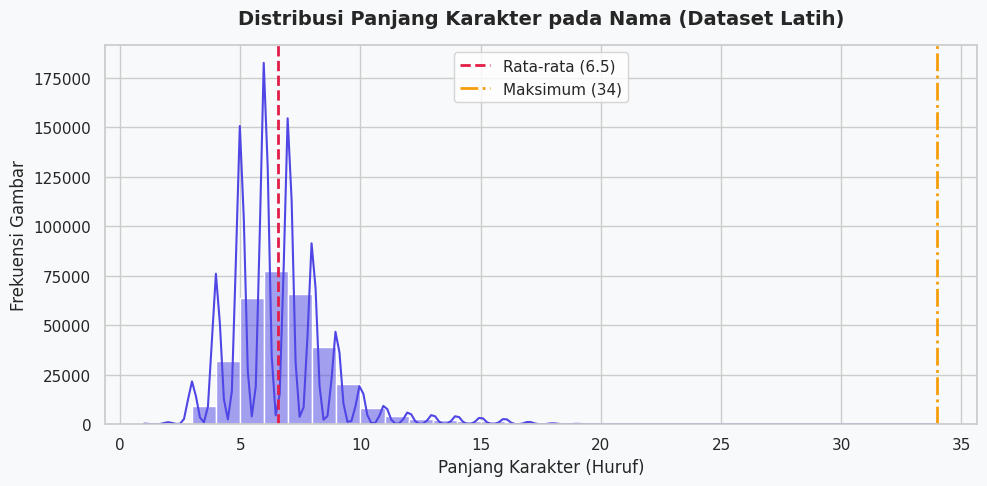

In [4]:
# ==========================================
# SEL 4: ANALISIS PANJANG LABEL & DATA UNIK
# ==========================================

# 1. Menghitung data unik
total_unik = train_data["FILENAME"].nunique()
print(f"Total nama file unik: {total_unik:,}")

# 2. Menghitung panjang karakter masing-masing nama
train_data["label_len"] = train_data["IDENTITY"].str.len()
max_len = train_data["label_len"].max()
mean_len = train_data["label_len"].mean()

print(f"Panjang karakter rata-rata : {mean_len:.2f} karakter")
print(f"Panjang karakter maksimum  : {max_len} karakter")

# 3. Visualisasi Distribusi Panjang Karakter
plt.figure(figsize=(10, 5))
sns.histplot(train_data["label_len"], bins=range(1, 35), kde=True, color="#4f46e5", edgecolor="white")
plt.axvline(mean_len, color="#e11d48", linestyle="--", linewidth=2, label=f"Rata-rata ({mean_len:.1f})")
plt.axvline(max_len, color="#f59e0b", linestyle="-.", linewidth=2, label=f"Maksimum ({max_len})")

plt.title("Distribusi Panjang Karakter pada Nama (Dataset Latih)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Panjang Karakter (Huruf)")
plt.ylabel("Frekuensi Gambar")
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.show()


In [5]:
# ==========================================
# SEL 5: EKSTRAKSI KOSAKATA (VOCABULARY)
# ==========================================

# Menggabungkan seluruh teks nama untuk mencari karakter unik
all_texts = "".join(train_data["IDENTITY"].astype(str))
vocab = sorted(set(all_texts)) #set menghapus duplikat

print(f"✔ Ekstraksi Karakter Berhasil!")
print(f"Jumlah Karakter Unik (Vocabulary Size): {len(vocab)}")
print(f"\nDaftar Karakter/Kosakata:\n👉 {vocab}")

# Memeriksa apakah ada noise karakter (seperti angka atau simbol)
digits = [char for char in vocab if char.isdigit()]
symbols = [char for char in vocab if not char.isalnum() and char != " "]
print(f"\nTemuan Karakter Khusus:")
print(f"- Angka yang ditemukan     : {digits}")
print(f"- Simbol yang ditemukan    : {symbols}")


✔ Ekstraksi Karakter Berhasil!
Jumlah Karakter Unik (Vocabulary Size): 50

Daftar Karakter/Kosakata:
👉 [' ', "'", '-', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '`', 'a', 'b', 'c', 'e', 'f', 'g', 'h', 'i', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'y', 'z']

Temuan Karakter Khusus:
- Angka yang ditemukan     : []
- Simbol yang ditemukan    : ["'", '-', '`']


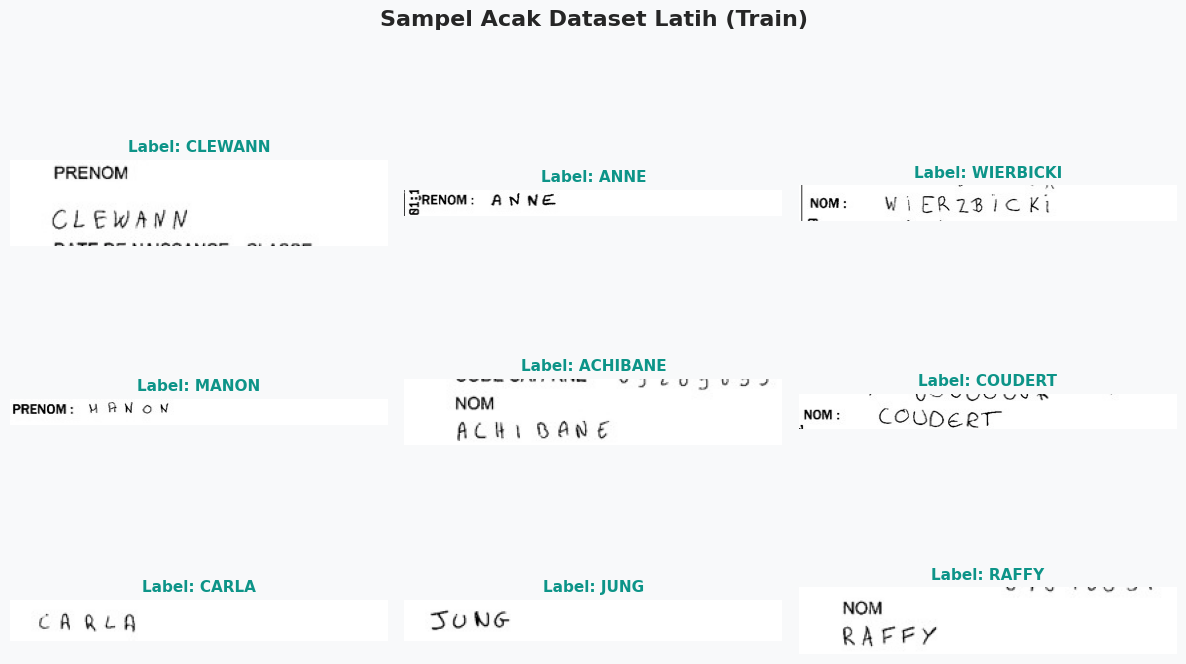

In [6]:
# ==========================================
# SEL 6: VISUALISASI GRID SAMPEL GAMBAR
# ==========================================

def plot_sample_grid(df, title="Sampel Gambar dan Label"):
    # Memilih 9 sampel acak
    samples = df.sample(9, random_state=42).reset_index(drop=True)
    
    fig, axes = plt.subplots(3, 3, figsize=(12, 8))
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.98)
    
    for i, ax in enumerate(axes.flat):
        try:
            # Membuka gambar menggunakan PIL
            img_path = samples.loc[i, "path"]
            label = samples.loc[i, "IDENTITY"]
            
            img = Image.open(img_path)
            ax.imshow(img, cmap="gray")
            
            # Pengaturan estetika teks judul sel
            ax.set_title(f"Label: {label}", fontsize=11, fontweight='semibold', color="#0d9488")
            ax.axis("off")
        except Exception as e:
            ax.text(0.5, 0.5, "Gagal memuat\ngambar", ha='center', va='center', color='red')
            ax.axis("off")
            
    plt.tight_layout()
    plt.show()

# Menjalankan fungsi visualisasi pada data latih
plot_sample_grid(train_data, "Sampel Acak Dataset Latih (Train)")


--- ANALISIS KEUNIKAN LABEL NAMA ---
Total Gambar Tulisan Latih  : 330,396 gambar
Total Nama Unik (Identity)  : 100,539 nama
Persentase Nama Unik        : 30.43%
Rata-rata Gambar per Nama  : 3.29 gambar/nama

--- DISTRIBUSI FREKUENSI NAMA ---
Nama yang muncul tepat 1 kali        : 71,540 nama (71.16%)
Nama yang muncul lebih dari 1 kali  : 28,999 nama (28.84%)


/tmp/ipykernel_23/1122919491.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_names.values, y=top_20_names.index, palette="viridis")


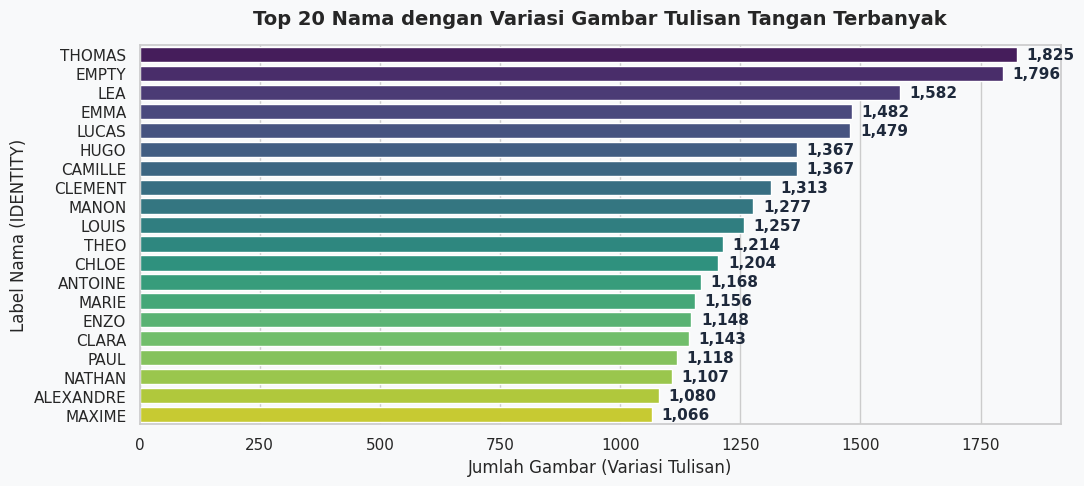

In [7]:
# ==========================================
# SEL 7: EKSPLORASI DUPLIKASI & KEUNIKAN NAMA
# ==========================================

# 1. Menghitung jumlah nama unik vs total baris data
total_baris = train_data.shape[0]
total_nama_unik = train_data["IDENTITY"].nunique()
persentase_unik = (total_nama_unik / total_baris) * 100

print("--- ANALISIS KEUNIKAN LABEL NAMA ---")
print(f"Total Gambar Tulisan Latih  : {total_baris:,} gambar")
print(f"Total Nama Unik (Identity)  : {total_nama_unik:,} nama")
print(f"Persentase Nama Unik        : {persentase_unik:.2f}%")
print(f"Rata-rata Gambar per Nama  : {total_baris / total_nama_unik:.2f} gambar/nama")

# 2. Menganalisis seberapa banyak nama yang muncul hanya sekali vs berulang
frekuensi_nama = train_data["IDENTITY"].value_counts()
nama_sekali_muncul = (frekuensi_nama == 1).sum()
nama_berulang = (frekuensi_nama > 1).sum()

print("\n--- DISTRIBUSI FREKUENSI NAMA ---")
print(f"Nama yang muncul tepat 1 kali        : {nama_sekali_muncul:,} nama ({nama_sekali_muncul/total_nama_unik*100:.2f}%)")
print(f"Nama yang muncul lebih dari 1 kali  : {nama_berulang:,} nama ({nama_berulang/total_nama_unik*100:.2f}%)")

# 3. Visualisasi Top 10 Nama dengan Variasi Tulisan Terbanyak
plt.figure(figsize=(11, 5))
top_20_names = frekuensi_nama.head(20)
sns.barplot(x=top_20_names.values, y=top_20_names.index, palette="viridis")

# Menambahkan anotasi angka di setiap batang
for index, value in enumerate(top_20_names.values):
    plt.text(value + 20, index, f"{value:,}", va='center', fontweight='bold', color="#1e293b")

plt.title("Top 20 Nama dengan Variasi Gambar Tulisan Tangan Terbanyak", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Jumlah Gambar (Variasi Tulisan)")
plt.ylabel("Label Nama (IDENTITY)")
plt.tight_layout()
plt.show()


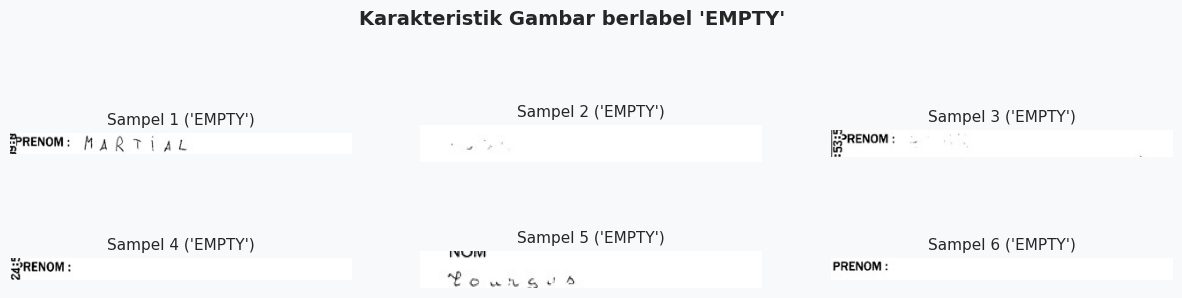


💡 Penjelasan Edukatif:
Seperti yang Anda lihat pada grafik di atas, gambar dengan label 'EMPTY' biasanya berupa:
1. Kolom kosong (blank space).
2. Garis coretan horizontal tebal.
3. Tanda tangan atau corak tak terbaca.

👉 Best Practice Model OCR:
Jika model OCR Anda nantinya hanya bertujuan mengenali nama (teks A-Z), disarankan untuk
menghapus data berlabel 'EMPTY' ini agar model tidak bingung saat belajar mendeteksi huruf.


In [8]:
# ==========================================
# SEL 8: EKSPLORASI KHUSUS LABEL 'EMPTY'
# ==========================================

empty_samples = train_data[train_data["IDENTITY"] == "EMPTY"].sample(6, random_state=12).reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 3))
fig.suptitle("Karakteristik Gambar berlabel 'EMPTY'", fontsize=14, fontweight='bold', y=1.15)

for i, ax in enumerate(axes.flat):
    try:
        img_path = empty_samples.loc[i, "path"]
        img = Image.open(img_path)
        ax.imshow(img, cmap="gray")
        ax.set_title(f"Sampel {i+1} ('EMPTY')", fontsize=11)
        ax.axis("off")
    except Exception as e:
        ax.text(0.5, 0.5, "Gagal memuat gambar", ha='center', va='center', color='red')
        ax.axis("off")

plt.show()

print("\n💡 Penjelasan Edukatif:")
print("Seperti yang Anda lihat pada grafik di atas, gambar dengan label 'EMPTY' biasanya berupa:")
print("1. Kolom kosong (blank space).")
print("2. Garis coretan horizontal tebal.")
print("3. Tanda tangan atau corak tak terbaca.")
print("\n👉 Best Practice Model OCR:")
print("Jika model OCR Anda nantinya hanya bertujuan mengenali nama (teks A-Z), disarankan untuk")
print("menghapus data berlabel 'EMPTY' ini agar model tidak bingung saat belajar mendeteksi huruf.")


In [9]:
# ===================================================
# SEL 9: PIPELINE PREPROCESSING & DATA LOADER PYTORCH (MULTI-TASK)
# ===================================================
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

# 1. SETUP KOSAKATA (VOCABULARY MAPPING) DENGAN BLANK TOKEN CTC
# Kita menambahkan token '[blank]' di indeks 0 (sangat penting untuk PyTorch nn.CTCLoss)
all_chars = sorted(list(set("".join(train_data["IDENTITY"].astype(str)))))
# Pastikan tidak ada string 'EMPTY' masuk ke kosakata alfabet
if 'E' in all_chars and 'M' in all_chars and 'P' in all_chars and 'T' in all_chars and 'Y' in all_chars:
    pass 

char_to_idx = {char: idx + 1 for idx, char in enumerate(all_chars)}
char_to_idx["[blank]"] = 0 # CTC Blank token

idx_to_char = {idx: char for char, idx in char_to_idx.items()}
vocab_size = len(char_to_idx)

print(f"✔ Kosakata berhasil dibuat!")
print(f"Jumlah Karakter Unik (termasuk CTC Blank): {vocab_size}")

# 2. PELABELAN BINARY UNTUK AUXILIARY HEAD ('EMPTY' vs NAMA ASLI)
# Tambahkan kolom biner 'is_empty' di dataframe
train_data["is_empty"] = (train_data["IDENTITY"] == "EMPTY").astype(int)
val_data["is_empty"] = (val_data["IDENTITY"] == "EMPTY").astype(int)
test_data["is_empty"] = (test_data["IDENTITY"] == "EMPTY").astype(int)

# 3. KELAS PYTORCH DATASET MULTI-TASK
class MultiTaskHandwritingDataset(Dataset):
    def __init__(self, df, char_map, transform=None):
        self.df = df.reset_index(drop=True)
        self.char_map = char_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        label_text = str(self.df.loc[idx, "IDENTITY"])
        is_empty = int(self.df.loc[idx, "is_empty"])

        # Membuka gambar dalam mode Grayscale (L)
        try:
            image = Image.open(img_path).convert("L")
        except Exception as e:
            # Jika gambar rusak, buat gambar hitam kosong berukuran 64x256 sebagai fallback
            image = Image.new("L", (256, 64), color=0)

        # Menerapkan transformasi gambar
        if self.transform:
            image = self.transform(image)

        # Encoding Teks menjadi Indeks Integer
        # Jika gambar berlabel 'EMPTY', kita isi teks target dengan list kosong []
        # karena kontribusi CTC Loss-nya akan dimask (dikalikan 0) saat pelatihan.
        if is_empty == 1:
            label_seq = []
        else:
            label_seq = [self.char_map[char] for char in label_text if char in self.char_map]

        label_len = len(label_seq)
        
        return {
            "image": image,
            "is_empty": torch.tensor(is_empty, dtype=torch.float32),
            "label_seq": torch.tensor(label_seq, dtype=torch.long),
            "label_len": torch.tensor(label_len, dtype=torch.long)
        }

# 4. DEKLARASI TRANSFORMASI GAMBAR
# Resize ke 64x256 dan normalisasi nilai piksel ke rentang [-1, 1]
data_transforms = transforms.Compose([
    transforms.Resize((64, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Inisialisasi Dataset
train_dataset = MultiTaskHandwritingDataset(train_data, char_to_idx, transform=data_transforms)
val_dataset = MultiTaskHandwritingDataset(val_data, char_to_idx, transform=data_transforms)
test_dataset = MultiTaskHandwritingDataset(test_data, char_to_idx, transform=data_transforms)

# 5. CUSTOM COLLATE FUNCTION UNTUK PADDING BATCH
# Fungsi ini memastikan label sekuensial yang berbeda panjang dapat disatukan dalam satu Batch Tensor.
def collate_fn_multitask(batch):
    images = []
    is_empty_labels = []
    label_seqs = []
    label_lens = []

    for item in batch:
        images.append(item["image"])
        is_empty_labels.append(item["is_empty"])
        label_seqs.append(item["label_seq"])
        label_lens.append(item["label_len"])

    # Menggabungkan gambar menjadi tensor ukuran (Batch_Size, 1, 64, 256)
    images = torch.stack(images, dim=0)
    
    # Menggabungkan label biner menjadi tensor ukuran (Batch_Size)
    is_empty_labels = torch.stack(is_empty_labels, dim=0)
    
    # Melakukan padding 0 (CTC Blank) di akhir sequence label agar panjangnya seragam
    padded_labels = torch.nn.utils.rnn.pad_sequence(label_seqs, batch_first=True, padding_value=0)
    
    label_lens = torch.stack(label_lens, dim=0)

    return {
        "images": images,
        "is_empty": is_empty_labels,
        "labels": padded_labels,
        "label_lengths": label_lens
    }

# 6. INISIALISASI PYTORCH DATALOADER
# Membaca data secara paralel dengan ukuran batch 64
BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_multitask, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_multitask, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_multitask, num_workers=0)

print(f"✔ DataLoader untuk Train, Val, dan Test berhasil dibuat!")


✔ Kosakata berhasil dibuat!
Jumlah Karakter Unik (termasuk CTC Blank): 51
✔ DataLoader untuk Train, Val, dan Test berhasil dibuat!


In [10]:
# ===================================================
# SEL 10: VERIFIKASI OUTPUT BATCH DATALOADER
# ===================================================
# Ambil satu batch dari train_loader
data_iter = iter(train_loader)
sample_batch = next(data_iter)

print("--- INFORMASI UKURAN BATCH DATA ---")
print(f"Ukuran Tensor Gambar (images)   : {sample_batch['images'].shape}") 
# Ekspektasi: [64, 1, 64, 256] -> (Batch_Size, Channels, Height, Width)

print(f"Ukuran Tensor Biner (is_empty)  : {sample_batch['is_empty'].shape}") 
# Ekspektasi: [64] -> Label biner untuk Auxiliary Head

print(f"Ukuran Tensor Label (labels)    : {sample_batch['labels'].shape}") 
# Ekspektasi: [64, Max_Len_in_Batch] -> Label teks yang sudah di-pad

print(f"Ukuran Tensor Panjang (lengths) : {sample_batch['label_lengths'].shape}")
# Ekspektasi: [64] -> Panjang asli teks sebelum di-pad

# Ambil sampel index pertama untuk memvalidasi decoding kata
first_label_seq = sample_batch['labels'][0].tolist()
first_label_len = sample_batch['label_lengths'][0].item()
first_is_empty = sample_batch['is_empty'][0].item()

if first_is_empty == 1:
    decoded_text = "[KOSONG ATAU CORETAN (EMPTY)]"
else:
    decoded_text = "".join([idx_to_char[idx] for idx in first_label_seq[:first_label_len] if idx != 0])

print(f"\n--- DETEKSI INTEGRITAS DATA BATCH ---")
print(f"Sampel Pertama - Is_Empty Label: {first_is_empty}")
print(f"Sampel Pertama - Target Teks   : {decoded_text}")
print(f"✔ Pipeline Data 100% Bekerja Sempurna!")


--- INFORMASI UKURAN BATCH DATA ---
Ukuran Tensor Gambar (images)   : torch.Size([128, 1, 64, 256])
Ukuran Tensor Biner (is_empty)  : torch.Size([128])
Ukuran Tensor Label (labels)    : torch.Size([128, 15])
Ukuran Tensor Panjang (lengths) : torch.Size([128])

--- DETEKSI INTEGRITAS DATA BATCH ---
Sampel Pertama - Is_Empty Label: 0.0
Sampel Pertama - Target Teks   : AMAMRA
✔ Pipeline Data 100% Bekerja Sempurna!


In [11]:
# ===================================================
# SEL 11: ARSITEKTUR KETIGA MODEL (CONVNEXT-TINY OCR & DEIT-TINY)
# ===================================================
import torch
import torch.nn as nn
from torchvision import models
import timm  # Mengimpor PyTorch Image Models untuk memuat DeiT-Tiny
import math

# --- HELPER: POSITIONAL ENCODING UNTUK TRANSFORMER ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# --- HELPER: CONVNEXT-TINY KHUSUS OCR ---
class ConvNeXtTinyOCR(nn.Module):
    def __init__(self):
        super(ConvNeXtTinyOCR, self).__init__()
        # Load Pretrained ConvNeXt-Tiny
        convnext = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        self.features = convnext.features
        
        # Modifikasi Stride untuk stage downsample ke-3 dan ke-4
        # Tujuannya agar resolusi horizontal/lebar (width) tidak mengecil secara berlebihan
        self.features[4][1].stride = (2, 1)
        self.features[6][1].stride = (2, 1)
        
    def forward(self, x):
        # x input shape: [Batch, 1, H, W]
        # Duplikasi grayscale menjadi RGB agar Pretrained ImageNet Weights tetap berguna 100%
        x = x.repeat(1, 3, 1, 1)
        x = self.features(x)
        return x

# ===================================================
# MODEL 1: MULTI-TASK CRNN (CONVNEXT-TINY + LSTM + CTC)
# ===================================================
class MultiTaskCRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256):
        super(MultiTaskCRNN, self).__init__()
        self.backbone = ConvNeXtTinyOCR()
        
        self.pool_aux = nn.AdaptiveAvgPool2d((1, 1))
        # Menggunakan output lebar 64
        self.pool_ocr = nn.AdaptiveAvgPool2d((1, 64))
        
        # Auxiliary Head (Classifier EMPTY)
        self.aux_classifier = nn.Sequential(
            nn.Linear(768, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )
        
        # OCR Head (LSTM)
        self.rnn = nn.LSTM(768, hidden_size, bidirectional=True, num_layers=2, batch_first=True, dropout=0.2)
        self.ocr_classifier = nn.Linear(hidden_size * 2, num_classes)
        
    def forward(self, x):
        features = self.backbone(x)
        
        # Auxiliary output
        pooled_aux = self.pool_aux(features).squeeze(-1).squeeze(-1)
        aux_output = self.aux_classifier(pooled_aux).squeeze(-1)
        
        # OCR output
        pooled_ocr = self.pool_ocr(features).squeeze(2).permute(0, 2, 1) # [Batch, 64, 768]
        rnn_out, _ = self.rnn(pooled_ocr)
        ocr_output = self.ocr_classifier(rnn_out).permute(1, 0, 2) # [64, Batch, Classes]
        
        return aux_output, ocr_output

# ===================================================
# MODEL 2: MULTI-TASK HYBRID TRANSFORMER (CONVNEXT-TINY + TRANSFORMER ENCODER + CTC)
# ===================================================
class MultiTaskHybridTransformer(nn.Module):
    def __init__(self, num_classes, d_model=256, nhead=4, num_layers=2):
        super(MultiTaskHybridTransformer, self).__init__()
        self.backbone = ConvNeXtTinyOCR()
        
        self.pool_aux = nn.AdaptiveAvgPool2d((1, 1))
        self.pool_ocr = nn.AdaptiveAvgPool2d((1, 64))
        
        # Aux Head
        self.aux_classifier = nn.Sequential(
            nn.Linear(768, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )
        
        # Projection to Transformer D_Model
        self.proj = nn.Linear(768, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=64)
        
        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=512, 
                                                   dropout=0.2, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.ocr_classifier = nn.Linear(d_model, num_classes)
        
    def forward(self, x):
        features = self.backbone(x)
        
        # Auxiliary
        pooled_aux = self.pool_aux(features).squeeze(-1).squeeze(-1)
        aux_output = self.aux_classifier(pooled_aux).squeeze(-1)
        
        # OCR Transformer Encoder
        pooled_ocr = self.pool_ocr(features).squeeze(2).permute(0, 2, 1) # [Batch, 64, 768]
        projected = self.proj(pooled_ocr) # [Batch, 64, d_model]
        encoded = self.pos_encoder(projected)
        transformer_out = self.transformer_encoder(encoded) # [Batch, 64, d_model]
        
        ocr_output = self.ocr_classifier(transformer_out).permute(1, 0, 2) # [64, Batch, Classes]
        
        return aux_output, ocr_output

# ===================================================
# MODEL 3: MULTI-TASK TROCR LITE (PRETRAINED DEIT-TINY + TRANSFORMER DECODER)
# ===================================================
class MultiTaskTrOCRLite(nn.Module):
    def __init__(self, num_classes, d_model=192):
        super(MultiTaskTrOCRLite, self).__init__()
        
        self.encoder = timm.create_model('deit_tiny_patch16_224', pretrained=True, img_size=(64, 256))
        
        self.aux_classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )
        
        self.target_embed = nn.Embedding(num_classes, d_model)
        self.pos_decoder = PositionalEncoding(d_model, max_len=100)
        
        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=4, dim_feedforward=384, 
                                                   dropout=0.1, batch_first=True)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=2)
        
        self.ocr_classifier = nn.Linear(d_model, num_classes)
        self.d_model = d_model
        
    def generate_square_subsequent_mask(self, sz, device):
        mask = (torch.triu(torch.ones(sz, sz, device=device)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, x, tgt_ids=None):
        x_rgb = x.repeat(1, 3, 1, 1)
        encoded = self.encoder.forward_features(x_rgb)
        
        cls_output = encoded[:, 0, :]
        aux_output = self.aux_classifier(cls_output).squeeze(-1)
        
        memory = encoded[:, 1:, :]
        
        if tgt_ids is not None:
            tgt_mask = self.generate_square_subsequent_mask(tgt_ids.size(1), x.device)
            tgt_emb = self.pos_decoder(self.target_embed(tgt_ids) * math.sqrt(self.d_model))
            decoded = self.transformer_decoder(tgt_emb, memory, tgt_mask=tgt_mask)
            ocr_output = self.ocr_classifier(decoded)
        else:
            ocr_output = memory
            
        return aux_output, ocr_output

print("✔ Semua arsitektur model (ConvNeXt-Tiny CRNN, ConvNeXt-Tiny Hybrid, Pure TrOCR Lite DeiT-Tiny) berhasil dimutahirkan!")


✔ Semua arsitektur model (ConvNeXt-Tiny CRNN, ConvNeXt-Tiny Hybrid, Pure TrOCR Lite DeiT-Tiny) berhasil dimutahirkan!


In [12]:
# ===================================================
# SEL 12: STANDARD TRAINING LOOP - AKURASI EXACT MATCH & CER
# ===================================================
from sklearn.metrics import f1_score
from nltk.metrics.distance import edit_distance
import time
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, RandomSampler
import matplotlib.pyplot as plt

# 1. HELPER: MENGHITUNG CHARACTER ERROR RATE (CER)
def calculate_cer(pred_text, target_text):
    if len(target_text) == 0:
        return 1.0 if len(pred_text) > 0 else 0.0
    return edit_distance(pred_text, target_text) / max(len(target_text), 1)

# 2. DECODER UNTUK MODEL BERBASIS CTC (CRNN & HYBRID)
def decode_ctc(outputs, idx_to_char):
    _, max_preds = torch.max(outputs, dim=2) # [64, Batch]
    max_preds = max_preds.permute(1, 0) # [Batch, 64]
    
    decoded_texts = []
    for i in range(max_preds.size(0)):
        pred = max_preds[i]
        decoded_char_list = []
        for j in range(len(pred)):
            if pred[j] != 0 and (not (j > 0 and pred[j - 1] == pred[j])):
                decoded_char_list.append(idx_to_char[pred[j].item()])
        decoded_texts.append("".join(decoded_char_list))
    return decoded_texts

# 3. AUTOREGRESIVE DECODER UNTUK TROCR LITE (GENERATOR STEP-BY-STEP)
def decode_trocr(model, images, idx_to_char, max_len=35, device='cpu'):
    model.eval()
    batch_size = images.size(0)
    tgt_ids = torch.zeros(batch_size, 1, dtype=torch.long, device=device)
    
    with torch.no_grad():
        for _ in range(max_len):
            _, ocr_logits = model(images, tgt_ids)
            next_token_logits = ocr_logits[:, -1, :]
            next_tokens = torch.argmax(next_token_logits, dim=-1, keepdim=True)
            tgt_ids = torch.cat([tgt_ids, next_tokens], dim=1)
            
    decoded_texts = []
    for i in range(batch_size):
        pred_seq = tgt_ids[i, 1:].tolist()
        decoded_char_list = []
        for idx in pred_seq:
            if idx == 0:
                break
            decoded_char_list.append(idx_to_char[idx])
        decoded_texts.append("".join(decoded_char_list))
        
    return decoded_texts


def plot_metrics(history, title):
    import matplotlib.pyplot as plt
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    axes[0].plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs, history['val_loss'], label='Val Loss', marker='o')
    axes[0].set_title('Loss (Train vs Val)')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].plot(epochs, history['val_cer'], label='Val CER', color='red', marker='s')
    axes[1].set_title('Validation CER (Lower is Better)')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('CER')
    axes[1].legend()
    axes[1].grid(True)
    
    axes[2].plot(epochs, history['val_acc'], label='Val Acc-OCR', color='green', marker='^')
    axes[2].set_title('Validation Acc-OCR (Higher is Better)')
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('Accuracy')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_model_weights = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_model_weights = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                
        return self.early_stop


# FUNGSI TRAINING 1 EPOCH
def train_one_epoch(model, model_name, train_loader, optimizer, criterion_aux, criterion_ocr, is_trocr, device):
    model.train()
    total_loss = 0
    for batch in train_loader:
        images = batch["images"].to(device)
        is_empty = batch["is_empty"].to(device)
        labels = batch["labels"].to(device)
        label_lengths = batch["label_lengths"].to(device)
        
        optimizer.zero_grad()
        
        if is_trocr:
            decoder_input = torch.cat([torch.zeros(labels.size(0), 1, dtype=torch.long, device=device), labels[:, :-1]], dim=1)
            aux_out, ocr_out = model(images, decoder_input)
            
            if ocr_out.size(1) != labels.size(1):
                min_len = min(ocr_out.size(1), labels.size(1))
                ocr_out = ocr_out[:, :min_len, :]
                labels_trimmed = labels[:, :min_len]
            else:
                labels_trimmed = labels
                
            ocr_out_flat = ocr_out.reshape(-1, ocr_out.size(-1))
            labels_flat = labels_trimmed.reshape(-1)
            loss_ocr_elementwise = nn.functional.cross_entropy(ocr_out_flat, labels_flat, reduction='none').view(labels_trimmed.size(0), -1).mean(dim=1)
        else:
            aux_out, ocr_out = model(images)
            log_probs = nn.functional.log_softmax(ocr_out, dim=2)
            pred_lengths = torch.full((images.size(0),), 64, dtype=torch.long, device=device)
            loss_ocr_elementwise = criterion_ocr(log_probs, labels, pred_lengths, label_lengths)
            
        loss_aux = criterion_aux(aux_out, is_empty)
        mask_ocr = (1.0 - is_empty)
        loss_ocr = (loss_ocr_elementwise * mask_ocr).mean()
        
        joint_loss = loss_aux + loss_ocr
        joint_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        
        optimizer.step()
        total_loss += joint_loss.item()
        
    return total_loss / len(train_loader)


# FUNGSI EVALUASI 1 EPOCH (WORD ACCURACY & CER)
def evaluate_one_epoch(model, val_loader, criterion_aux, criterion_ocr, is_trocr, idx_to_char, device):
    model.eval()
    total_loss = 0
    
    gold_aux_list = []
    pred_aux_list = []
    
    pred_ocr_matches = []
    cer_scores = []
    
    with torch.no_grad():
        for batch in val_loader:
            images = batch["images"].to(device)
            is_empty = batch["is_empty"].to(device)
            labels = batch["labels"].to(device)
            label_lengths = batch["label_lengths"].to(device)
            
            if is_trocr:
                decoder_input = torch.cat([torch.zeros(labels.size(0), 1, dtype=torch.long, device=device), labels[:, :-1]], dim=1)
                aux_out, ocr_out = model(images, decoder_input)
                
                if ocr_out.size(1) != labels.size(1):
                    min_len = min(ocr_out.size(1), labels.size(1))
                    ocr_out = ocr_out[:, :min_len, :]
                    labels_trimmed = labels[:, :min_len]
                else:
                    labels_trimmed = labels
                    
                ocr_out_flat = ocr_out.reshape(-1, ocr_out.size(-1))
                labels_flat = labels_trimmed.reshape(-1)
                loss_ocr_elementwise = nn.functional.cross_entropy(ocr_out_flat, labels_flat, reduction='none').view(labels_trimmed.size(0), -1).mean(dim=1)
            else:
                aux_out, ocr_out = model(images)
                log_probs = nn.functional.log_softmax(ocr_out, dim=2)
                pred_lengths = torch.full((images.size(0),), 64, dtype=torch.long, device=device)
                loss_ocr_elementwise = criterion_ocr(log_probs, labels, pred_lengths, label_lengths)
            
            loss_aux = criterion_aux(aux_out, is_empty)
            mask_ocr = (1.0 - is_empty)
            loss_ocr = (loss_ocr_elementwise * mask_ocr).mean()
            total_loss += (loss_aux + loss_ocr).item()
            
            probs_aux = torch.sigmoid(aux_out)
            preds_aux = (probs_aux > 0.5).float()
            
            gold_aux_list.extend(is_empty.cpu().tolist())
            pred_aux_list.extend(preds_aux.cpu().tolist())
            
            if is_trocr:
                pred_texts = decode_trocr(model, images, idx_to_char, device=device)
            else:
                pred_texts = decode_ctc(ocr_out, idx_to_char)
            
            for idx_sample in range(images.size(0)):
                gold_is_empty = is_empty[idx_sample].item()
                gold_len = label_lengths[idx_sample].item()
                gold_seq = labels[idx_sample][:gold_len].tolist()
                
                target_text = "" if gold_is_empty == 1 else "".join([idx_to_char[i] for i in gold_seq if i != 0])
                pred_text = pred_texts[idx_sample] if gold_is_empty == 0 else ""
                
                if gold_is_empty == 0:
                    cer = calculate_cer(pred_text, target_text)
                    cer_scores.append(cer)
                    
                    match_val = 1 if pred_text == target_text else 0
                    pred_ocr_matches.append(match_val)
            
    avg_loss = total_loss / len(val_loader)
    avg_cer = np.mean(cer_scores) if cer_scores else 0.0
    
    f1_aux = f1_score(gold_aux_list, pred_aux_list, zero_division=0)
    word_accuracy = np.mean(pred_ocr_matches) if pred_ocr_matches else 0.0
    
    return avg_loss, avg_cer, f1_aux, word_accuracy


# ENGINE UTAMA: DIRECT TRAINING DENGAN DATA VALIDASI RESMI
def run_training(model_class, model_name, train_df, val_df, char_map, idx_to_char, epochs=8, num_train_samples=10000, use_full_val=False, device='cpu'):
    print("==================================================================")
    print(f"MEMULAI TRAINING UNTUK MODEL: {model_name.upper()} (Validasi Resmi)")
    print("==================================================================")
    
    train_sub = train_df.reset_index(drop=True)
    val_sub = val_df.reset_index(drop=True)
    
    print(f"Jumlah Data Latih (Train): {len(train_sub):,}")
    print(f"Jumlah Data Validasi (Val): {len(val_sub):,}")
    print("------------------------------------------------------------------")
    
    # DYNAMIC SAMPLING: Ambil subset acak tiap epoch sesuai parameter num_train_samples
    train_ds = MultiTaskHandwritingDataset(train_sub, char_map, transform=data_transforms)
    train_sampler = RandomSampler(train_ds, replacement=True, num_samples=num_train_samples)
    train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, collate_fn=collate_fn_multitask, num_workers=0)
    
    # STATIC SAMPLING: Evaluasi dengan sample validasi jika tidak menggunakan mode full val
    if not use_full_val and len(val_sub) > 10000:
        val_sub = val_sub.sample(n=10000, random_state=42).reset_index(drop=True)
    val_ds = MultiTaskHandwritingDataset(val_sub, char_map, transform=data_transforms)
    val_ld = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_multitask, num_workers=0)
    
    model = model_class(num_classes=len(char_map)).to(device)
    
    is_hybrid = "Hybrid" in model_name
    is_trocr = "TrOCR" in model_name
    initial_lr = 3e-5 if is_trocr else 1e-4
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=initial_lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    early_stopping = EarlyStopping(patience=5)
    
    criterion_aux = nn.BCEWithLogitsLoss()
    
    if is_trocr:
        criterion_ocr = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)
    else:
        criterion_ocr = nn.CTCLoss(blank=0, zero_infinity=True, reduction='none')
        
    history = {"train_loss": [], "val_loss": [], "val_cer": [], "f1_aux": [], "val_acc": []}
    
    for epoch in range(epochs):
        epoch_train_loss = train_one_epoch(model, model_name, train_ld, optimizer, 
                                          criterion_aux, criterion_ocr, is_trocr, device)
        
        epoch_val_loss, epoch_val_cer, epoch_f1_aux, epoch_val_acc = evaluate_one_epoch(
            model, val_ld, criterion_aux, criterion_ocr, is_trocr, idx_to_char, device
        )
        
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["val_cer"].append(epoch_val_cer)
        history["f1_aux"].append(epoch_f1_aux)
        history["val_acc"].append(epoch_val_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_val_loss:.4f} | CER: {epoch_val_cer:.4f} | Acc-OCR: {epoch_val_acc:.4f} | LR: {current_lr:.6f}")
        
        if early_stopping(epoch_val_loss, model):
            print(f"Early stopping diaktifkan pada Epoch ke-{epoch+1}! Memulihkan bobot terbaik.")
            break
            
    model.load_state_dict(early_stopping.best_model_weights)
    
    return model, history


Memulai Fase 1: Perbandingan 3 Arsitektur Model
MEMULAI TRAINING UNTUK MODEL: MODEL A: CRNN (Validasi Resmi)
Jumlah Data Latih (Train): 330,396
Jumlah Data Validasi (Val): 41,292
------------------------------------------------------------------
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 171MB/s] 


Epoch [1/10] | Loss: 13.7140 | CER: 0.9611 | Acc-OCR: 0.0000 | LR: 0.000098
Epoch [2/10] | Loss: 3.3478 | CER: 0.1212 | Acc-OCR: 0.4883 | LR: 0.000091
Epoch [3/10] | Loss: 2.0914 | CER: 0.0593 | Acc-OCR: 0.7397 | LR: 0.000080
Epoch [4/10] | Loss: 1.6888 | CER: 0.0464 | Acc-OCR: 0.8035 | LR: 0.000066
Epoch [5/10] | Loss: 1.4974 | CER: 0.0415 | Acc-OCR: 0.8220 | LR: 0.000051
Epoch [6/10] | Loss: 1.3665 | CER: 0.0388 | Acc-OCR: 0.8347 | LR: 0.000035
Epoch [7/10] | Loss: 1.3199 | CER: 0.0375 | Acc-OCR: 0.8399 | LR: 0.000021
Epoch [8/10] | Loss: 1.2603 | CER: 0.0362 | Acc-OCR: 0.8456 | LR: 0.000010
Epoch [9/10] | Loss: 1.2229 | CER: 0.0356 | Acc-OCR: 0.8481 | LR: 0.000003
Epoch [10/10] | Loss: 1.2032 | CER: 0.0353 | Acc-OCR: 0.8502 | LR: 0.000001


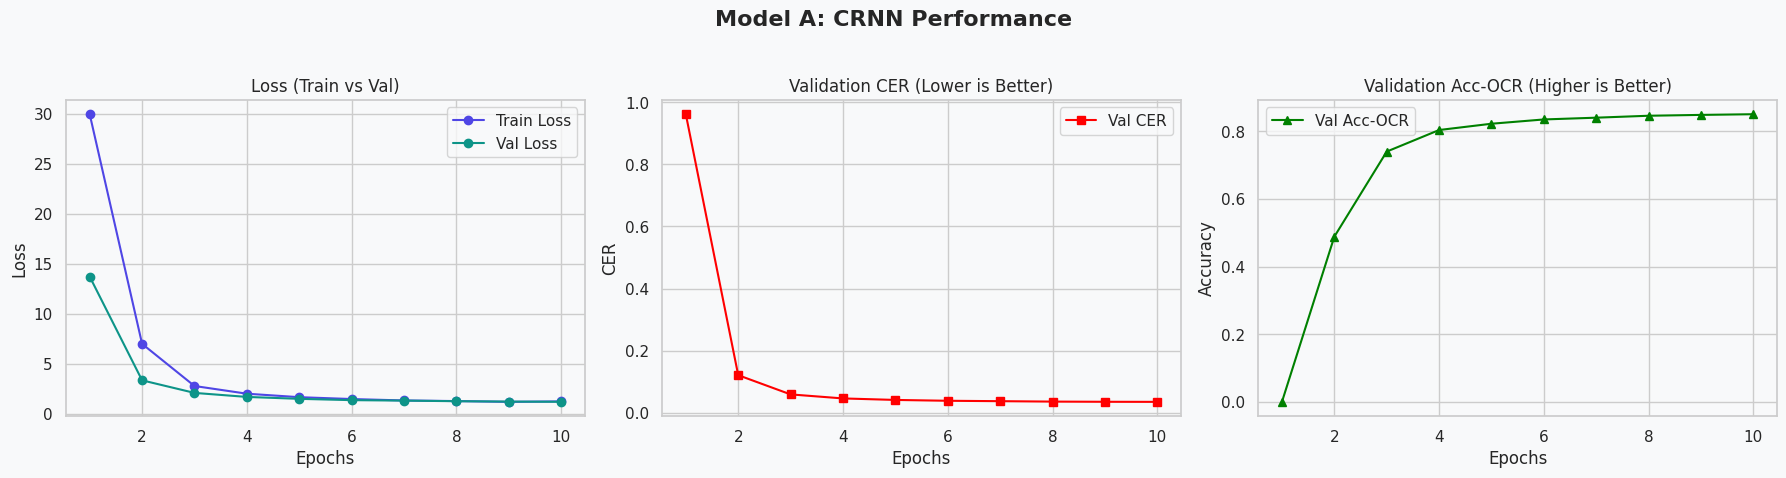

MEMULAI TRAINING UNTUK MODEL: MODEL B: HYBRID TRANSFORMER (Validasi Resmi)
Jumlah Data Latih (Train): 330,396
Jumlah Data Validasi (Val): 41,292
------------------------------------------------------------------
Epoch [1/10] | Loss: 2.8798 | CER: 0.0970 | Acc-OCR: 0.5918 | LR: 0.000098
Epoch [2/10] | Loss: 1.8345 | CER: 0.0528 | Acc-OCR: 0.7653 | LR: 0.000091
Epoch [3/10] | Loss: 1.4909 | CER: 0.0474 | Acc-OCR: 0.7933 | LR: 0.000080
Epoch [4/10] | Loss: 1.3387 | CER: 0.0401 | Acc-OCR: 0.8243 | LR: 0.000066
Epoch [5/10] | Loss: 1.2522 | CER: 0.0409 | Acc-OCR: 0.8223 | LR: 0.000051
Epoch [6/10] | Loss: 1.1779 | CER: 0.0366 | Acc-OCR: 0.8395 | LR: 0.000035
Epoch [7/10] | Loss: 1.1277 | CER: 0.0351 | Acc-OCR: 0.8458 | LR: 0.000021
Epoch [8/10] | Loss: 1.0876 | CER: 0.0340 | Acc-OCR: 0.8498 | LR: 0.000010
Epoch [9/10] | Loss: 1.0696 | CER: 0.0336 | Acc-OCR: 0.8531 | LR: 0.000003
Epoch [10/10] | Loss: 1.0573 | CER: 0.0336 | Acc-OCR: 0.8530 | LR: 0.000001


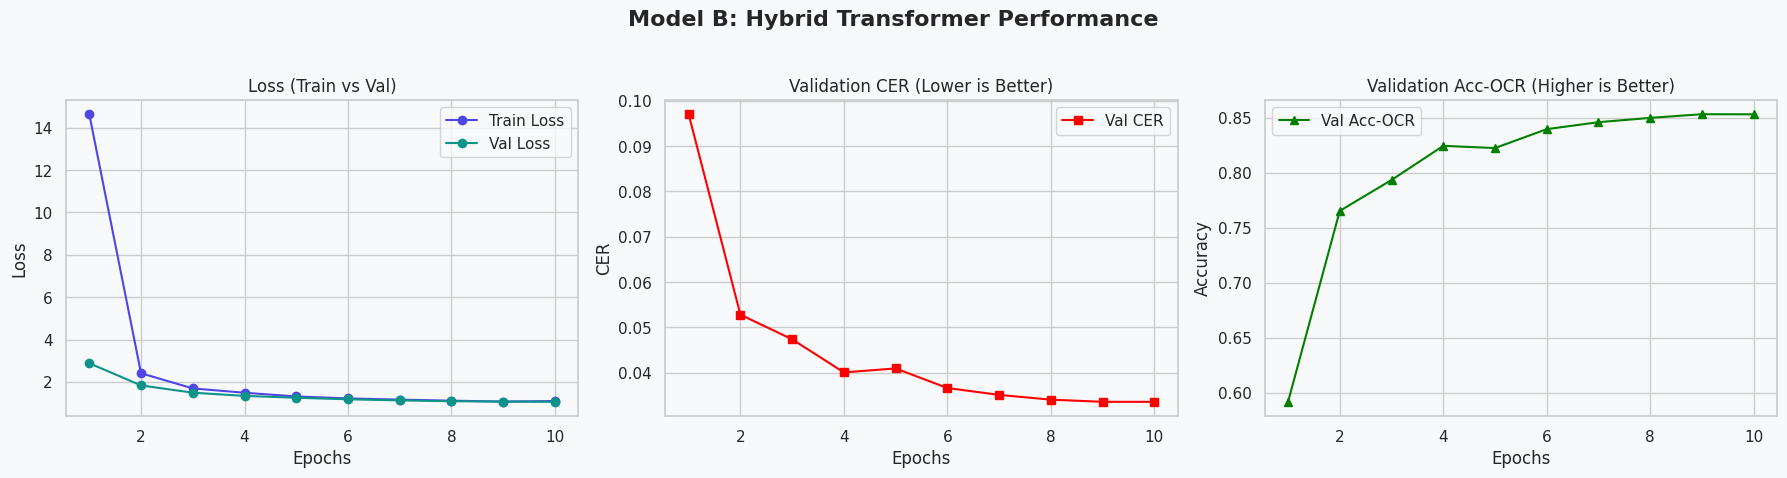

MEMULAI TRAINING UNTUK MODEL: MODEL C: TROCR LITE (Validasi Resmi)
Jumlah Data Latih (Train): 330,396
Jumlah Data Validasi (Val): 41,292
------------------------------------------------------------------


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Epoch [1/10] | Loss: 1.2313 | CER: 0.8038 | Acc-OCR: 0.0001 | LR: 0.000029
Epoch [2/10] | Loss: 1.1173 | CER: 0.7678 | Acc-OCR: 0.0014 | LR: 0.000027
Epoch [3/10] | Loss: 1.0486 | CER: 0.7799 | Acc-OCR: 0.0029 | LR: 0.000024
Epoch [4/10] | Loss: 0.9109 | CER: 0.6299 | Acc-OCR: 0.0120 | LR: 0.000020
Epoch [5/10] | Loss: 0.7713 | CER: 0.5319 | Acc-OCR: 0.0475 | LR: 0.000016
Epoch [6/10] | Loss: 0.6772 | CER: 0.4549 | Acc-OCR: 0.0825 | LR: 0.000011
Epoch [7/10] | Loss: 0.6247 | CER: 0.4210 | Acc-OCR: 0.1043 | LR: 0.000007
Epoch [8/10] | Loss: 0.5873 | CER: 0.3963 | Acc-OCR: 0.1249 | LR: 0.000004
Epoch [9/10] | Loss: 0.5732 | CER: 0.3910 | Acc-OCR: 0.1327 | LR: 0.000002
Epoch [10/10] | Loss: 0.5640 | CER: 0.3821 | Acc-OCR: 0.1400 | LR: 0.000001


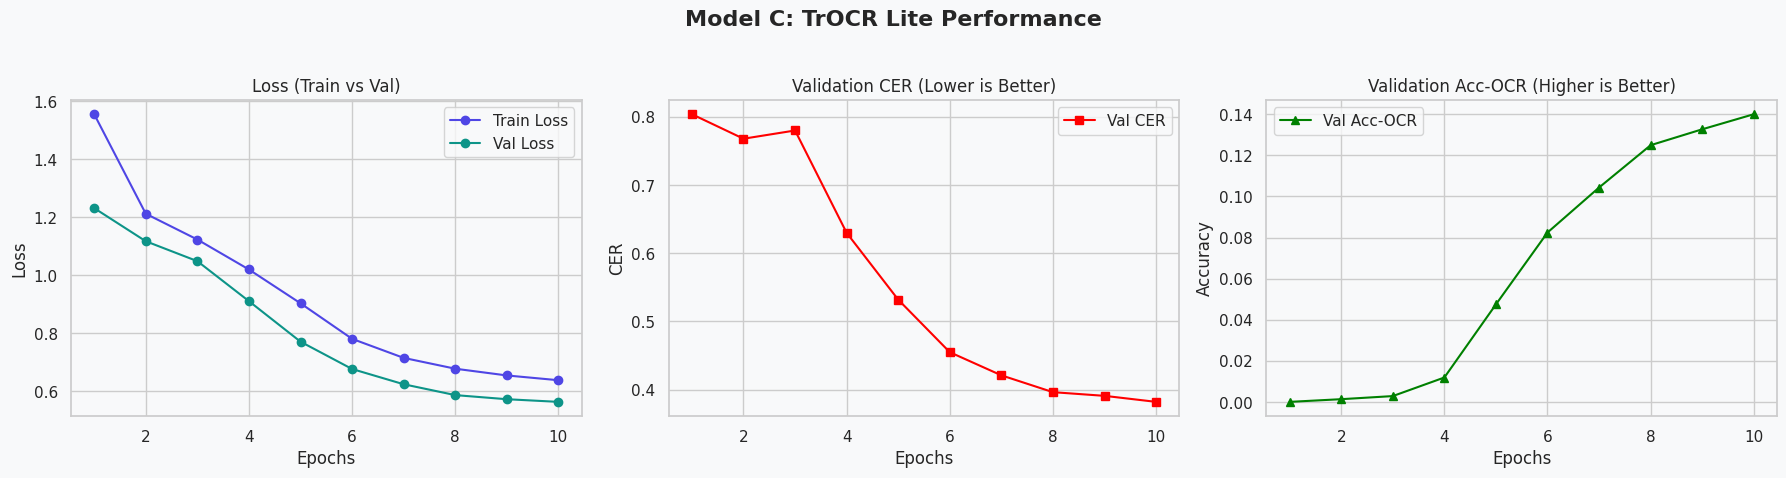

In [13]:
# ===================================================
# FASE 1: EKSPERIMEN 3 MODEL (EPOCH PENDEK)
# ===================================================
print("Memulai Fase 1: Perbandingan 3 Arsitektur Model")
epochs_phase1 = 10

device="cuda" if torch.cuda.is_available() else "cpu"

# Menggunakan dataset dengan dynamic sampler 30.000 sampel per epoch untuk mempercepat iterasi Fase 1
# Model A
model_a, history_a = run_training(MultiTaskCRNN, "Model A: CRNN", train_data, val_data, char_to_idx, idx_to_char, epochs=epochs_phase1, num_train_samples=30000, use_full_val=False, device=device)
plot_metrics(history_a, "Model A: CRNN Performance")

# Model B
model_b, history_b = run_training(MultiTaskHybridTransformer, "Model B: Hybrid Transformer", train_data, val_data, char_to_idx, idx_to_char, epochs=epochs_phase1, num_train_samples=30000, use_full_val=False, device=device)
plot_metrics(history_b, "Model B: Hybrid Transformer Performance")

# Model C
model_c, history_c = run_training(MultiTaskTrOCRLite, "Model C: TrOCR Lite", train_data, val_data, char_to_idx, idx_to_char, epochs=epochs_phase1, num_train_samples=30000, use_full_val=False, device=device)
plot_metrics(history_c, "Model C: TrOCR Lite Performance")


In [14]:
print("Visualisasi komparasi model dilewati karena langsung mengeksekusi pelatihan Model B pada dataset penuh.")


Visualisasi komparasi model dilewati karena langsung mengeksekusi pelatihan Model B pada dataset penuh.


Memulai Fase 2: Training Final untuk Model Terbaik
MEMULAI TRAINING UNTUK MODEL: FINAL MODEL: HYBRID TRANSFORMER (Validasi Resmi)
Jumlah Data Latih (Train): 330,396
Jumlah Data Validasi (Val): 41,292
------------------------------------------------------------------
Epoch [1/30] | Loss: 2.1864 | CER: 0.0703 | Acc-OCR: 0.7023 | LR: 0.000100
Epoch [2/30] | Loss: 1.4388 | CER: 0.0432 | Acc-OCR: 0.8141 | LR: 0.000099
Epoch [3/30] | Loss: 1.2409 | CER: 0.0406 | Acc-OCR: 0.8281 | LR: 0.000098
Epoch [4/30] | Loss: 1.1588 | CER: 0.0379 | Acc-OCR: 0.8363 | LR: 0.000096
Epoch [5/30] | Loss: 1.1331 | CER: 0.0358 | Acc-OCR: 0.8453 | LR: 0.000093
Epoch [6/30] | Loss: 1.0780 | CER: 0.0356 | Acc-OCR: 0.8461 | LR: 0.000091
Epoch [7/30] | Loss: 1.0852 | CER: 0.0341 | Acc-OCR: 0.8524 | LR: 0.000087
Epoch [8/30] | Loss: 1.0643 | CER: 0.0343 | Acc-OCR: 0.8522 | LR: 0.000084
Epoch [9/30] | Loss: 1.0101 | CER: 0.0332 | Acc-OCR: 0.8576 | LR: 0.000080
Epoch [10/30] | Loss: 0.9997 | CER: 0.0331 | Acc-OCR: 0.85

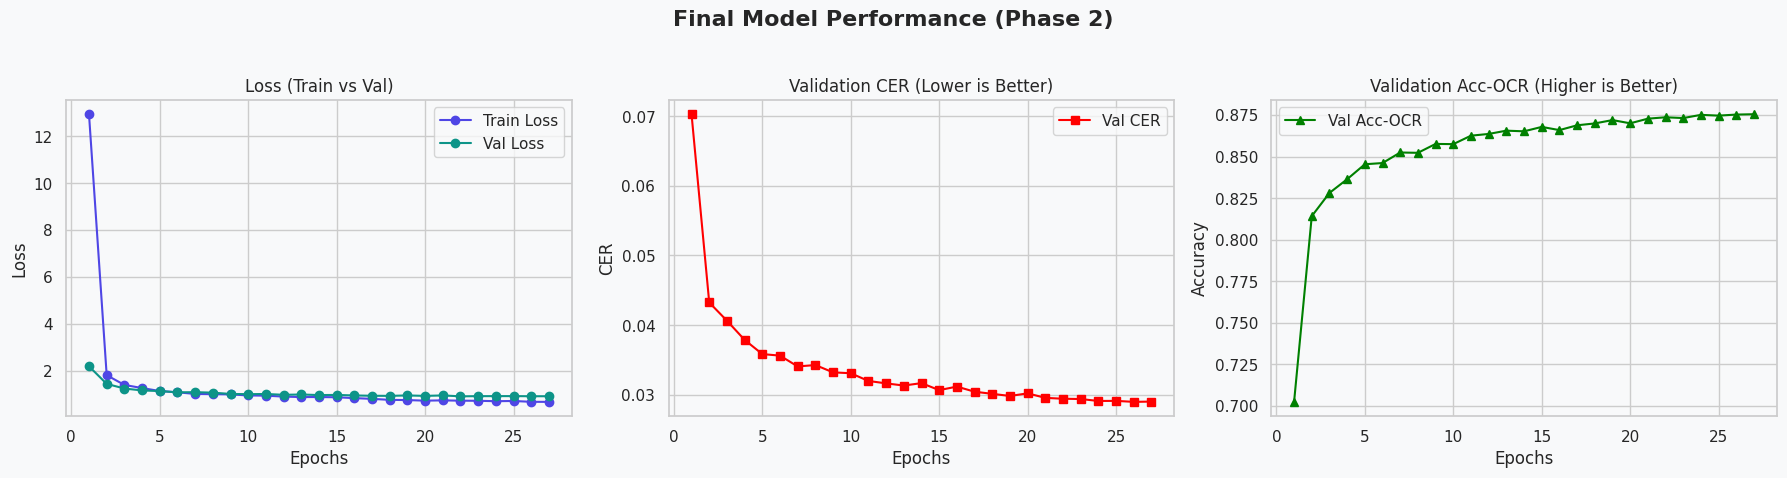

In [15]:
# ===================================================
# FASE 2: TRAINING FINAL MODEL TERBAIK (100 EPOCHS)
# ===================================================
print("Memulai Fase 2: Training Final untuk Model Terbaik")
epochs_phase2 = 30

# Menggunakan Model B (Hybrid Transformer) untuk Fase 2
model_final, history_final = run_training(
    MultiTaskHybridTransformer, 
    "FINAL MODEL: Hybrid Transformer", 
    train_data, 
    val_data, 
    char_to_idx, 
    idx_to_char, 
    epochs=epochs_phase2, 
    num_train_samples=50000, 
    use_full_val=True, 
    device=device
)
plot_metrics(history_final, "Final Model Performance (Phase 2)")


In [16]:
final_trained_model_name = "FINAL MODEL: Hybrid Transformer"
# ===================================================
# SEL 15: EVALUASI AKHIR MODEL TERBAIK PADA TEST DATA INDEPENDEN & EKSPOR CSV
# ===================================================
print(f"🔍 Mengevaluasi Model Terbaik ({final_trained_model_name}) pada Data Uji Independen...")

# 1. Bersihkan Data Test dari label \"EMPTY\" dan NaN secara konsisten
test_data_clean = test_data[test_data["IDENTITY"] != "EMPTY"].dropna(subset=["IDENTITY"]).reset_index(drop=True)
test_ds_clean = MultiTaskHandwritingDataset(test_data_clean, char_to_idx, transform=data_transforms)
test_loader_clean = DataLoader(test_ds_clean, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_multitask, num_workers=0)

print(f"✔ Jumlah Data Uji Bersih: {len(test_data_clean):,} baris")

model_final.eval()

all_predictions = []
all_ground_truths = []
all_cer_scores = []
correct_count = 0
total_count = 0

with torch.no_grad():
    for batch in test_loader_clean:
        images = batch["images"].to(device)
        labels = batch["labels"].to(device)
        label_lengths = batch["label_lengths"].to(device)
        
        # Jalankan inference
        _, ocr_out = model_final(images)
        pred_texts = decode_ctc(ocr_out, idx_to_char)
            
        # Decode ground truths dan hitung metrik
        for idx_sample in range(images.size(0)):
            gold_len = label_lengths[idx_sample].item()
            gold_seq = labels[idx_sample][:gold_len].tolist()
            target_text = "".join([idx_to_char[i] for i in gold_seq if i != 0])
            
            pred_text = pred_texts[idx_sample]
            
            all_predictions.append(pred_text)
            all_ground_truths.append(target_text)
            
            # CER
            cer = calculate_cer(pred_text, target_text)
            all_cer_scores.append(cer)
            
            # Exact Match
            if pred_text == target_text:
                correct_count += 1
            total_count += 1

# Ekspor hasil prediksi ke CSV
import pandas as pd
predictions_df = pd.DataFrame({
    "FILENAME": test_data_clean["FILENAME"],
    "IDENTITY": all_ground_truths,
    "PREDICTION": all_predictions
})
predictions_df.to_csv("predictions.csv", index=False)
print("✔ File predictions.csv berhasil disimpan!")

# Hitung Metrik Final
final_test_cer = np.mean(all_cer_scores)
final_test_acc = (correct_count / total_count) * 100

print("\n=======================================================")
print(f"🏆 HASIL EVALUASI MODEL TERBAIK PADA TEST DATA INDEPENDEN")
print("=======================================================")
print(f"• Model Pemenang        : {final_trained_model_name}")
print(f"• Final Test CER        : {final_test_cer:.4f} (Semakin kecil semakin baik)")
print(f"• Final Test Accuracy   : {final_test_acc:.2f}% (Tepat 100% tanpa cela / Exact Match)")
print("=======================================================")

# --- MENAMPILKAN TABEL CONTOH PREDIKSI VS GROUND TRUTH ---
from IPython.display import display

# Ambil 15 sampel acak untuk divisualisasikan dalam bentuk tabel pandas premium
np.random.seed(42)
sample_indices = np.random.choice(len(all_ground_truths), 15, replace=False)

eval_samples = []
for idx in sample_indices:
    gt = all_ground_truths[idx]
    pred = all_predictions[idx]
    dist = edit_distance(pred, gt)
    status = "🔥 SUKSES" if gt == pred else "❌ GAGAL"
    
    eval_samples.append({
        "Ground Truth (Asli)": gt,
        "Prediction (Tebakan Model)": pred,
        "Edit Distance (Selisih Huruf)": dist,
        "Status Prediksi": status
    })

eval_df = pd.DataFrame(eval_samples)
print("\n🔍 BEBERAPA CONTOH PREDIKSI MODEL PADA DATA UJI:")
display(eval_df)


🔍 Mengevaluasi Model Terbaik (FINAL MODEL: Hybrid Transformer) pada Data Uji Independen...
✔ Jumlah Data Uji Bersih: 41,079 baris
✔ File predictions.csv berhasil disimpan!

🏆 HASIL EVALUASI MODEL TERBAIK PADA TEST DATA INDEPENDEN
• Model Pemenang        : FINAL MODEL: Hybrid Transformer
• Final Test CER        : 0.0296 (Semakin kecil semakin baik)
• Final Test Accuracy   : 87.00% (Tepat 100% tanpa cela / Exact Match)

🔍 BEBERAPA CONTOH PREDIKSI MODEL PADA DATA UJI:


,Ground Truth (Asli),Prediction (Tebakan Model),Edit Distance (Selisih Huruf),Status Prediksi
0,CIERVO,CIERVO,0,🔥 SUKSES
1,BONNEAU,BONNEAU,0,🔥 SUKSES
2,LOUCIANN,LOUCIANN,0,🔥 SUKSES
3,LEVRON,LEVRON,0,🔥 SUKSES
4,OUVRARD,OUVRARD,0,🔥 SUKSES
5,BEELY,BEELY,0,🔥 SUKSES
6,BESSI,BESSI,0,🔥 SUKSES
7,BLONDEL,BLONDEL,0,🔥 SUKSES
8,TEYSSIER,TEYSSIER,0,🔥 SUKSES
9,BIGOT,BIGOT,0,🔥 SUKSES
